In [1]:
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.spatial.distance import squareform

import bonsai_loop as bl

sc.set_figure_params(figsize=(5, 5))
data_dir = Path("./data")

/home/stan/Git/bonsai-loop/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import inspect

from bonsai_loop.bonsai_lib.bonsai.bonsai_dataprocessing import (  # type: ignore[import]
    loadReconstructedTreeAndData,
)
from bonsai_loop.bonsai_lib.bonsai.bonsai_helpers import (  # type: ignore[import]
    Run_Configs,
)

# import relevant modules and functions
from bonsai_loop.bonsai_lib import (
    bonsai_clustering,
    get_bonsai_euclidean_distances,
    get_pdists_on_tree_euclidean,
)

print(inspect.getsource(loadReconstructedTreeAndData))
print(f"{'─' * 88}")
pprint(Run_Configs.__dict__)

def loadReconstructedTreeAndData(args, tree_folder, reprocess_data=False, all_genes=False, all_ranks=True,
                                 get_cell_info=False, corrected_data=True, rel_to_results=False, no_data_needed=False,
                                 single_process=False, keep_original_data=False, calc_loglik=False, get_data=True,
                                 get_posterior_ltqs=False, otherRanksMinimalInfo=False, verbose=True,
                                 calc_posteriors=True):
    """

    :param args:
    :param tree_folder:
    :param reprocess_data:
    :param all_genes:
    :param all_ranks:
    :param get_cell_info:
    :param corrected_data:
    :param rel_to_results:
    :param no_data_needed:
    :param single_process:
    :param keep_original_data:
    :param calc_loglik:
    :param get_data:
    :param get_posterior_ltqs:
    :param otherRanksMinimalInfo:
    :param verbose:
    :param calc_posteriors: This boolean may be false, even when get_posterior_ltqs i

AnnData object with n_obs × n_vars = 19245 × 29128
    obs: 'doublet', 'doublet_score', 'stage', 'sample', 'theiler_stage', 'cell_cluster', 'cell_type', 'color', 'UMAP_1', 'UMAP_2', 'sample_labels'
    uns: 'cell_type_colors'
    obsm: 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'


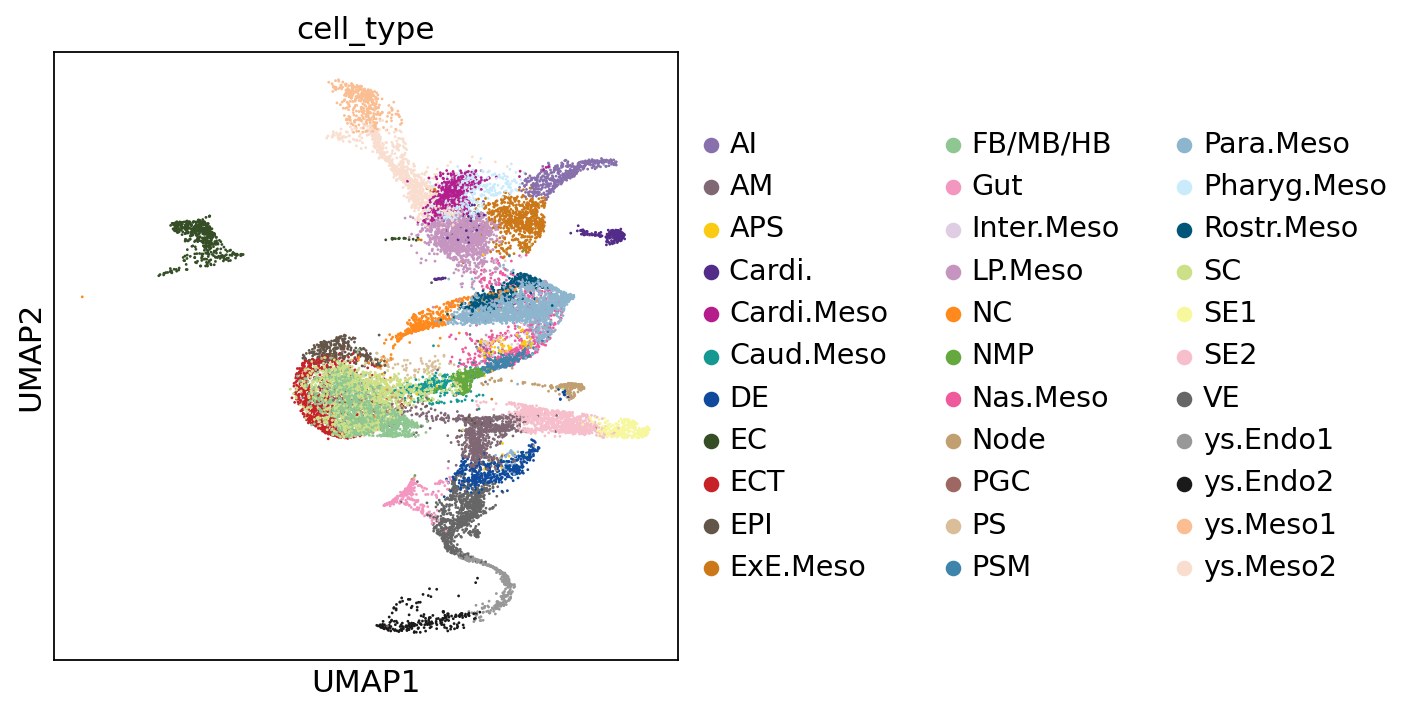

In [3]:
adata_monkey = sc.read_h5ad(data_dir / "adata_zhai_e2_CS9_CS11.h5ad")
print(adata_monkey)
sc.pl.umap(adata_monkey, color=["cell_type"])

# Visualize bonsai tree

In [4]:
bonsai_monkey_path = data_dir / "Bonsai_monkey"
monkey_bonsai_output_folder = bonsai_monkey_path / "final_bonsai_zscore1.0/"
monkey_bonsai_config_file = bonsai_monkey_path / "used_run_configs.yaml"

In [5]:
monkey_run_configs = Run_Configs(monkey_bonsai_config_file)
scData, vert_map = loadReconstructedTreeAndData(
    monkey_run_configs,
    monkey_bonsai_output_folder,
    rel_to_results=False,
    reprocess_data=False,
    all_ranks=False,
    get_cell_info=True,
    get_posterior_ltqs=True,
)
scData.tree.root.get_ds_info_for_ladderize()
# reroot
monkey_node_id_to_vert_ind = {}
with open(monkey_bonsai_output_folder / "vertInfo.txt") as f:
    next(f)
    for line in f:
        parts = line.strip().split("\t")
        monkey_node_id_to_vert_ind[parts[2]] = int(parts[0])
new_root = "internal_12142"
scData.tree.reset_root(monkey_node_id_to_vert_ind[new_root])
n_clusters = 15
nwk_str = scData.tree.to_newick(use_ids=True)
all_clusters, _ = bonsai_clustering.get_min_pdists_clustering_from_nwk_str(
    tree_nwk_str=nwk_str,
    n_clusters=n_clusters,
    cell_ids=adata_monkey.obs_names.tolist(),  # optional: restrict to AnnData cells
)
monkey_clusters = all_clusters[f"annot_bnsi_cluster_n{n_clusters}"]
cluster_dict = bonsai_clustering.get_cluster_assignments({"bonsai": monkey_clusters})
adata_monkey.obs["bonsai_cluster"] = (
    cluster_dict["bonsai"]
    .reindex(adata_monkey.obs.index)
    .fillna("-1")
    .astype("category")
)

05-29 09:45:15 mp_print INFO 

Reconstructed tree loaded from: 
data/Bonsai_monkey/final_bonsai_zscore1.0/edgeInfo.txt 
data/Bonsai_monkey/final_bonsai_zscore1.0/vertInfo.txt
05-29 09:45:16 mp_print INFO 
Init min-dist clustering-tree
05-29 09:45:16 mp_print INFO Clustering has created 2 subtrees, 13 branches still to cut.
05-29 09:45:16 mp_print INFO Clustering has created 4 subtrees, 11 branches still to cut.
05-29 09:45:16 mp_print INFO Clustering has created 8 subtrees, 7 branches still to cut.


Clustering done


In [6]:
node_data_lookup = bl.convergence.compute_tree_node_level_and_label(
    tree=scData.tree,
    node_level_type="topological",
    label_lookup_leaves=adata_monkey.obs["bonsai_cluster"].to_dict(),
)
bl.convergence.compute_bonsai_tree_dendrogram(
    tree=scData.tree,
    node_data_lookup=node_data_lookup,
    ladderize_by_annotated_leaves_only=True,
)

compute depth-first ordering of nodes
root node internal_12142
compute node level and label


34451it [00:00, 297383.33it/s]


In [7]:
print(node_data_lookup["root"])
print(node_data_lookup["E23-E2_CAATGACGTTTCGTTT-4"])

┌─────────────────────────────┬───────────────────────────────────────────────┐
│ attribute                   │ value                                         │
├─────────────────────────────┼───────────────────────────────────────────────┤
│ tree_node                   │ TreeNode(nodeId='root')                       │
│ topological_level           │ 67                                            │
│ geometric_level             │ None                                          │
│ identity                    │ [(cl_3,0.17), (cl_6,0.15), (cl_12,0.14), ...] │
│ n_leaves                    │ 9092                                          │
│ ordering_value              │ None                                          │
│ dendrogram_coords           │ (-0.8333763447667053, 0.20421658992657932)    │
│ delta_deviation_from_parent │ None                                          │
│ other_props                 │ None                                          │
└─────────────────────────────┴─────────

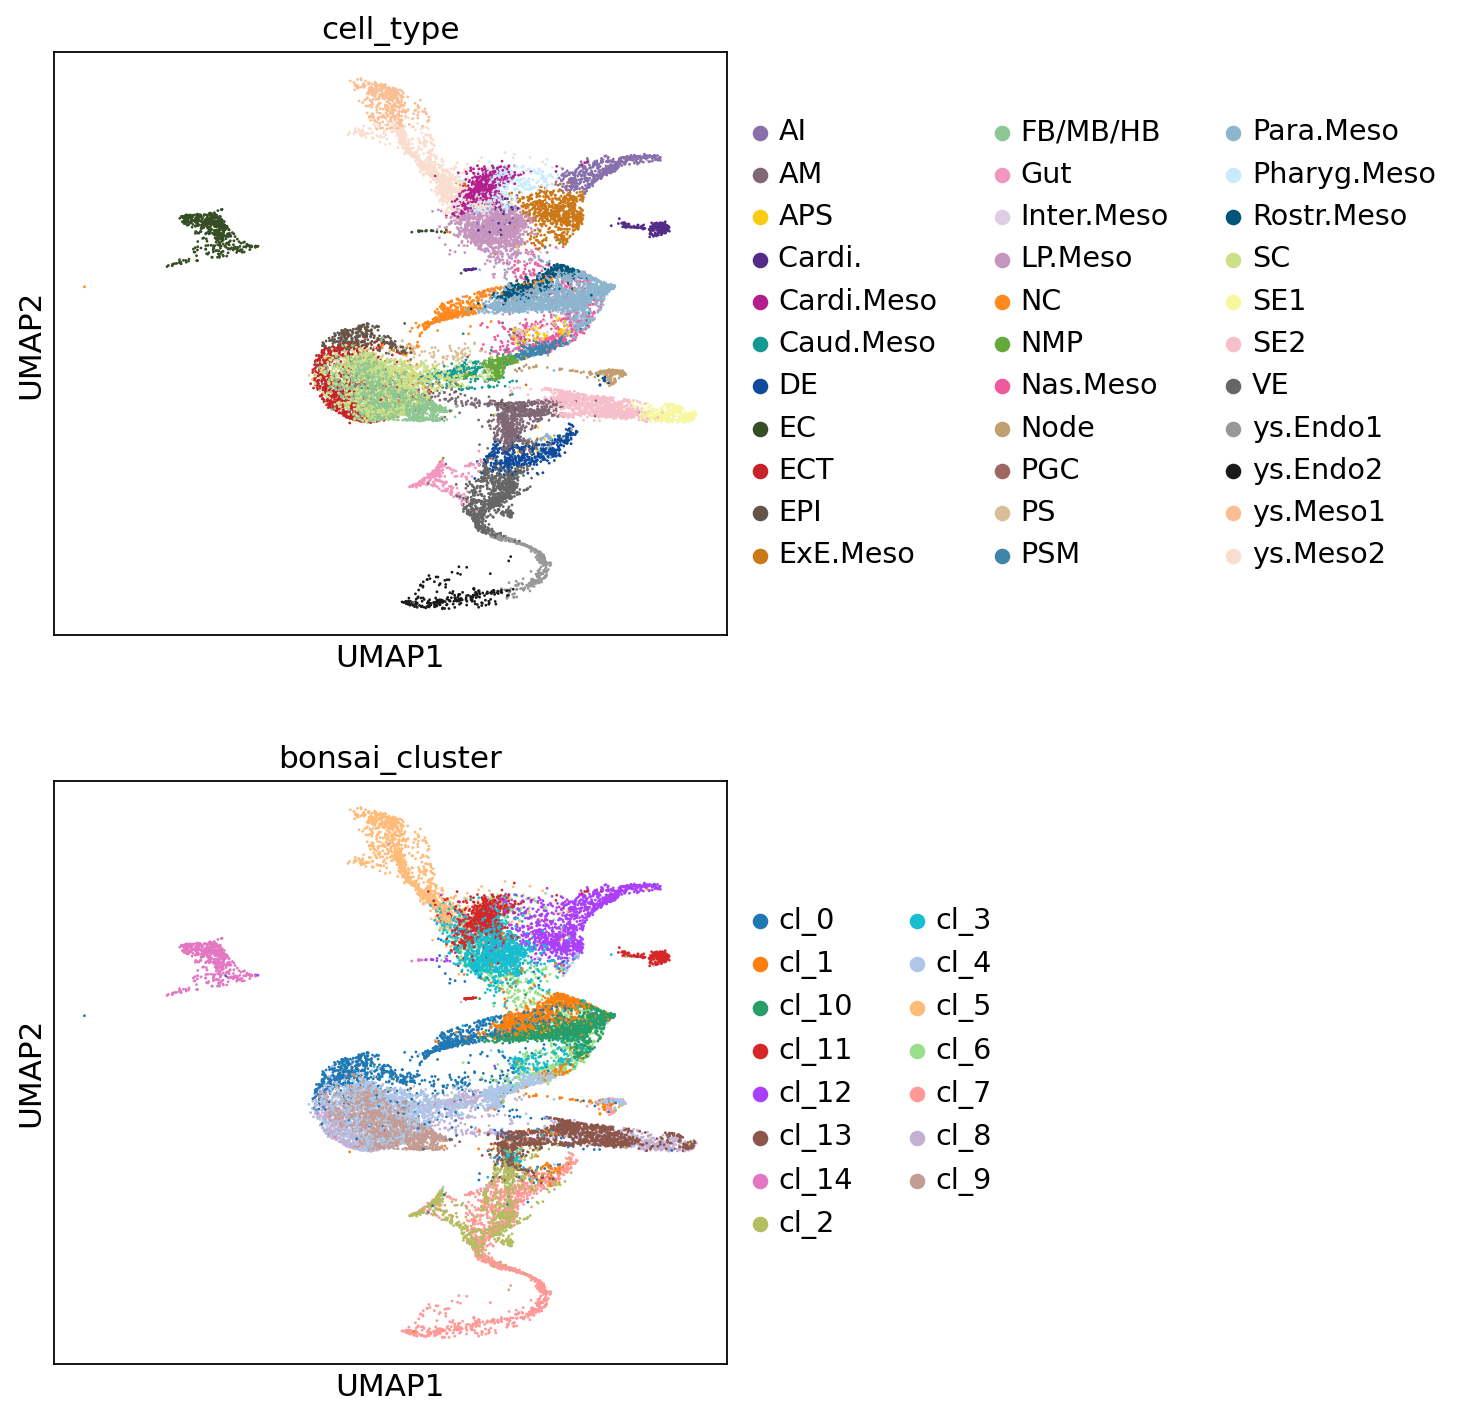

In [8]:
sc.pl.umap(adata_monkey, color=["cell_type", "bonsai_cluster"], ncols=1)

In [9]:
# plot dendrogram
xy = {nid: node_data_lookup[nid].dendrogram_coords for nid in node_data_lookup}
segs = []
for child_id in node_data_lookup.keys():
    parent = node_data_lookup[child_id].tree_node.parentNode
    if parent is None:
        continue
    parent_id = parent.nodeId
    px, py = xy[parent_id]
    cx, cy = xy[child_id]
    segs.append([(px, py), (px, cy), (cx, cy)])
xy = np.array(list(xy.values()))
monkey_cell_types = pd.Categorical(adata_monkey.obs["cell_type"]).categories
monkey_colors = adata_monkey.uns["cell_type_colors"]
color_pal = dict(zip(monkey_cell_types, monkey_colors))
cell_ids = [nid for nid, nd in node_data_lookup.items() if nd.tree_node.isLeaf]
cell_xy = np.array([node_data_lookup[cid].dendrogram_coords for cid in cell_ids])
cell_colors = [color_pal[adata_monkey.obs.loc[cid, "cell_type"]] for cid in cell_ids]

In [12]:
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 10))
lc = LineCollection(segs, colors="lightgray", linewidths=1, zorder=1)
ax.add_collection(lc)
ax.scatter(cell_xy[:, 0], cell_xy[:, 1], c=cell_colors, s=10, lw=0, zorder=1)
ax.set_axis_off()
ax.grid(False)
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=color_pal[ct],
        markersize=10,
        linestyle="",
        label=ct,
    )
    for ct in monkey_cell_types
]
ax.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=24,
    ncol=2,
)
plt.savefig("figures/monkey_dendrogram.png", dpi=300, bbox_inches="tight")
plt.close()

In [13]:
# due to speed issue, exclude some cell types (too many internal nodes)
monkey_cell_ids = list(
    adata_monkey.obs_names[
        ~adata_monkey.obs["cell_type"].str.contains("NC|SC|FB|AI|Cardi|EC")
    ]
)
rng = np.random.default_rng(0)
monkey_cell_ids = list(rng.choice(monkey_cell_ids, size=8000, replace=False))
print("compute straight distance")
monkey_euclidean_straight = squareform(
    get_bonsai_euclidean_distances(
        final_bonsai_folder=monkey_bonsai_output_folder,
        cell_ids=monkey_cell_ids,
    )
)

print("compute tree euclidean")
monkey_euclidean_tree = squareform(
    get_pdists_on_tree_euclidean(
        nwk_file=monkey_bonsai_output_folder / "tree.nwk",
        bonsai_output_folder=monkey_bonsai_output_folder,
        cell_ids=monkey_cell_ids,
    )
)
lo_pct, up_pct = 0.05, 0.95
straight_q = np.quantile(squareform(monkey_euclidean_straight), [lo_pct, up_pct])
tree_e_q = np.quantile(squareform(monkey_euclidean_tree), [lo_pct, up_pct])


def _rescale_to_tree_range(dists_condensed, src_q, tree_q):
    d = squareform(dists_condensed)
    d = (d - src_q[0]) / (src_q[1] - src_q[0]) * (tree_q[1] - tree_q[0]) + tree_q[0]
    return squareform(np.maximum(d, 0))


monkey_euclidean_straight_match = _rescale_to_tree_range(
    monkey_euclidean_straight, straight_q, tree_e_q
)

compute straight distance
compute tree euclidean


In [14]:
bl.convergence.compute_node_ordering_value(
    scData.tree, node_data_lookup, metric="dendrogram"
)
ordered_leaf_ids = bl.convergence.compute_node_ordering(
    node_data_lookup,
    level=0,
    sort_by_identity_first=False,
    ascending=True,
)
id_to_idx = {cid: i for i, cid in enumerate(monkey_cell_ids)}
monkey_reorder_ind = np.array(
    [id_to_idx[cid] for cid in ordered_leaf_ids if cid in id_to_idx]
)
cell_types = pd.Categorical(adata_monkey.obs["cell_type"]).categories

compute node ordering using metric dendrogram


In [15]:
monkey_colors = adata_monkey.uns["cell_type_colors"]
color_pal = dict(zip(cell_types, monkey_colors))

window_size = 20
composition = np.zeros((len(cell_types) + 1, len(monkey_cell_ids)))
for i, ct in enumerate(cell_types):
    res = np.convolve(
        (
            adata_monkey.obs.loc[monkey_cell_ids, "cell_type"].iloc[monkey_reorder_ind]
            == ct
        ).astype(float),
        np.ones(window_size),
        mode="valid",
    )
    margin = int(np.ceil((composition.shape[1] - res.shape[0]) / 2))
    res = np.pad(res, (margin, margin), mode="constant")
    composition[i, :] = res[: composition.shape[1]]
composition[-1, :] = 1
composition = composition / composition.sum(axis=0)


def _reorder(mat):
    return mat[monkey_reorder_ind, :][:, monkey_reorder_ind]


monkey_mat_tree_e = _reorder(monkey_euclidean_tree)
monkey_mat_straight = _reorder(monkey_euclidean_straight_match)
monkey_mat_diff = monkey_mat_tree_e - monkey_mat_straight

In [16]:
import gc
import pathlib

import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

FONTSIZE = 15
figure_dir = pathlib.Path("figures/monkey_contact_maps")
figure_dir.mkdir(parents=True, exist_ok=True)

heatmaps = [
    {
        "mat": monkey_mat_tree_e,
        "title": "Bonsai tree distance (euclidean)",
        "cmap": "viridis",
        "vmin_pct": 1,
        "vmax_pct": 99,
        "vmin": None,
        "vmax": None,
        "filename": "monkey_tree_distance_euclidean.png",
    },
    {
        "mat": monkey_mat_straight,
        "title": "Embedding euclidean distance",
        "cmap": "viridis",
        "vmin_pct": 25,
        "vmax_pct": 99,
        "vmin": None,
        "vmax": None,
        "filename": "monkey_embedding_euclidean.png",
    },
    {
        "mat": monkey_mat_diff,
        "title": "Bonsai tree distance (euclidean) - Embedding euclidean distance",
        "cmap": "cividis",
        "vmin_pct": 1,
        "vmax_pct": 99,
        "vmin": 0.1,
        "vmax": 0.8,
        "filename": "monkey_tree_minus_embedding_euclidean.png",
    },
]

for heatmap in heatmaps:
    plot_mat = (heatmap["mat"] + heatmap["mat"].T) / 2
    vmin_pct = heatmap["vmin_pct"] or 0
    vmax_pct = heatmap["vmax_pct"] or 100
    vmin = (
        np.percentile(plot_mat, vmin_pct)
        if heatmap["vmin"] is None
        else heatmap["vmin"]
    )
    vmax = (
        np.percentile(plot_mat, vmax_pct)
        if heatmap["vmax"] is None
        else heatmap["vmax"]
    )
    norm = Normalize(vmin=vmin, vmax=vmax)

    g = sns.clustermap(
        plot_mat,
        cmap=heatmap["cmap"],
        cbar=True,
        square=False,
        xticklabels=False,
        yticklabels=False,
        row_cluster=False,
        col_cluster=False,
        figsize=(10, 10),
        # rasterized=True,
        norm=norm,
    )
    ax_hm = g.ax_heatmap
    ax_hm.set_aspect("equal")
    ax_hm.grid(False)
    g.ax_row_dendrogram.set_visible(False)
    g.ax_col_dendrogram.set_visible(False)
    g.cax.set_visible(False)

    ax_hm.set_position([0.1, 0.08, 0.78, 0.78])
    pos = ax_hm.get_position()
    n = plot_mat.shape[0]
    x = np.arange(n)
    y = np.arange(n)

    tick = np.arange(0, n, 500)
    ax_hm.set_xticks(tick)
    ax_hm.set_xticklabels([str(int(t)) for t in tick], fontsize=FONTSIZE)
    ax_hm.set_yticks(tick)
    ax_hm.set_yticklabels([str(int(t)) for t in tick], fontsize=FONTSIZE)
    ax_hm.set_xlabel("cells", fontsize=FONTSIZE)
    ax_hm.set_ylabel("cells", fontsize=FONTSIZE)

    ax_top = g.fig.add_axes([pos.x0, pos.y1 + 0.01, pos.width, 0.05])
    ax_top.stackplot(x, composition[:-1, :], labels=cell_types, colors=monkey_colors)
    ax_top.set_xlim(ax_hm.get_xlim())
    ax_top.axis("off")
    ax_top.text(
        1.01,
        0.5,
        "cell identity",
        transform=ax_top.transAxes,
        ha="left",
        va="center",
        fontsize=FONTSIZE,
        clip_on=False,
    )

    ax_left = g.fig.add_axes([pos.x0 - 0.06, pos.y0, 0.05, pos.height])
    cumulative = np.cumsum(composition[:-1, :], axis=0)
    prev = np.zeros(n)
    for k in range(cumulative.shape[0]):
        ax_left.fill_betweenx(y, prev, cumulative[k], color=monkey_colors[k])
        prev = cumulative[k]
    ax_left.set_xlim(1, 0)
    ax_left.set_ylim(ax_hm.get_ylim())
    ax_left.axis("off")

    ax_top.set_title(heatmap["title"], fontsize=FONTSIZE * 1.5)
    mappable = ScalarMappable(norm=norm, cmap=heatmap["cmap"])
    mappable.set_array([])
    cax = g.fig.add_axes([pos.x0 - 0.03, 1.01, 0.1, 0.018])
    cb = g.fig.colorbar(mappable, cax=cax, orientation="horizontal")
    cb.set_label("value", fontsize=FONTSIZE, labelpad=4)
    if vmin < 0 < vmax:
        cb.set_ticks([vmin, 0, vmax], labels=[f"{vmin:.1f}", "0", f"{vmax:.1f}"])
    else:
        cb.set_ticks([vmin, vmax], labels=[f"{vmin:.1f}", f"{vmax:.1f}"])
    cb.ax.tick_params(labelsize=FONTSIZE)

    out = figure_dir / heatmap["filename"]
    g.fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.close(g.fig)
    gc.collect()
    print(f"saved {out}")

saved figures/monkey_contact_maps/monkey_tree_distance_euclidean.png
saved figures/monkey_contact_maps/monkey_embedding_euclidean.png
saved figures/monkey_contact_maps/monkey_tree_minus_embedding_euclidean.png
